# Atelier Seaborn — Analyse exploratoire des capteurs IoT

**Contexte :** une entreprise possède plusieurs bâtiments équipés de capteurs IoT qui collectent
température, humidité, pression, consommation énergétique, état du capteur, bâtiment, date/heure.

**Objectif :** réaliser une analyse exploratoire des données (EDA) avec Seaborn, en comprenant
**pourquoi** on fait chaque étape et **ce que fait** chaque ligne de code — pas seulement en
obtenant un résultat.

> Dans ce notebook : chaque partie commence par un rappel de l'objectif, le code est commenté
> ligne par ligne, et une interprétation des résultats suit chaque graphique.


## Installation et imports

**Objectif :** préparer l'environnement de travail avant toute analyse.
On installe (si besoin) et on importe les 4 bibliothèques nécessaires, puis on active le thème
Seaborn et l'affichage inline des graphiques dans le notebook.

In [ ]:
# pip install seaborn matplotlib pandas numpy  (à exécuter une seule fois si les packages manquent)

import seaborn as sns          # visualisation statistique (construit sur Matplotlib)
import matplotlib.pyplot as plt  # personnalisation fine des graphiques (titres, tailles, sauvegarde)
import pandas as pd            # manipulation de données tabulaires (DataFrame)
import numpy as np             # calcul numérique (utilisé ici en support, ex. pour les seuils)
import os                      # gestion des dossiers (création du dossier exports/)

sns.set_theme()   # applique le thème visuel par défaut de Seaborn (fond gris + grille blanche)

# Commande Jupyter (pas du Python standard) : affiche les graphiques directement sous chaque cellule
%matplotlib inline


## Import et vérification du dataset

**Objectif :** charger le CSV fourni dans un DataFrame Pandas nommé `df` (comme demandé dans la
consigne), puis vérifier sa structure avant de commencer l'analyse — c'est une étape indispensable :
on ne visualise jamais des données qu'on n'a pas d'abord inspectées.

In [26]:
# read_csv charge le fichier CSV dans un DataFrame
# parse_dates=["date_heure"] : convertit directement cette colonne en type datetime
# (sinon elle resterait du texte, inexploitable pour un tri chronologique ou un lineplot)
df = pd.read_csv("../data/mesures_capteurs.csv", parse_dates=["date_heure"])

df.head()  # affiche les 5 premières lignes pour un premier coup d'œil sur les colonnes et les valeurs

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [27]:
# .shape renvoie un tuple (nombre de lignes, nombre de colonnes)
print("Dimensions du dataset :", df.shape)

# .info() liste chaque colonne avec son type (dtype) et son nombre de valeurs non nulles
# -> permet de repérer d'un coup d'œil les colonnes avec des valeurs manquantes
df.info()

Dimensions du dataset : (605, 9)
<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_mesure     605 non-null    str           
 1   date_heure    605 non-null    datetime64[us]
 2   id_capteur    605 non-null    str           
 3   batiment      605 non-null    str           
 4   temperature   599 non-null    float64       
 5   humidite      600 non-null    float64       
 6   pression      600 non-null    float64       
 7   consommation  600 non-null    float64       
 8   etat          601 non-null    str           
dtypes: datetime64[us](1), float64(4), str(4)
memory usage: 42.7 KB


In [28]:
# .describe() calcule les statistiques descriptives (moyenne, écart-type, min, quartiles, max)
# UNIQUEMENT sur les colonnes numériques -> premier indice pour repérer des valeurs suspectes
df.describe()

,date_heure,temperature,humidite,pression,consommation
count,605,599.000000,600.00000,600.000000,600.000000
mean,2026-01-17 11:32:43.636363,24.878314,64.92620,1012.221900,208.675417
min,2026-01-05 00:00:00,-18.500000,28.52000,850.000000,18.120000
25%,2026-01-11 05:00:00,22.570000,58.17250,1006.790000,160.177500
50%,2026-01-17 12:00:00,24.860000,65.37500,1012.855000,206.150000
75%,2026-01-23 18:00:00,27.275000,71.61500,1017.827500,254.127500
max,2026-01-29 23:00:00,58.700000,145.00000,1038.430000,875.000000
std,NaN,4.059576,10.76905,10.599042,72.243567


In [29]:
# .isna() renvoie True/False pour chaque cellule selon qu'elle est vide (NaN) ou non
# .sum() compte ensuite le nombre de True par colonne (donc le nombre de valeurs manquantes)
print("Valeurs manquantes par colonne :")
df.isna().sum()

Valeurs manquantes par colonne :


id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

**Constat de cette étape :** le dataset comporte 605 mesures sur 4 bâtiments (`B001` à
`B004`). On note quelques valeurs manquantes (5 à 6 selon les colonnes numériques, 4 sur `etat`) et,
dans `describe()`, des valeurs suspectes : une humidité maximale de 145 % (impossible, une humidité
relative va de 0 à 100 %), une pression minimale à 850 hPa (anormalement basse) et une consommation
maximale de 875 alors que la moyenne est ~209 — autant de **valeurs extrêmes** à garder en tête pour
la suite de l'analyse.

# Partie 1 — Distribution d'une variable avec `histplot()`

**Objectif de `histplot()` :** découper les valeurs d'une variable numérique en intervalles (bins)
et compter combien d'observations tombent dans chaque intervalle — cela révèle la **forme** de la
distribution (où sont concentrées les valeurs, y a-t-il des extrêmes...).

### 1) Afficher la distribution des températures

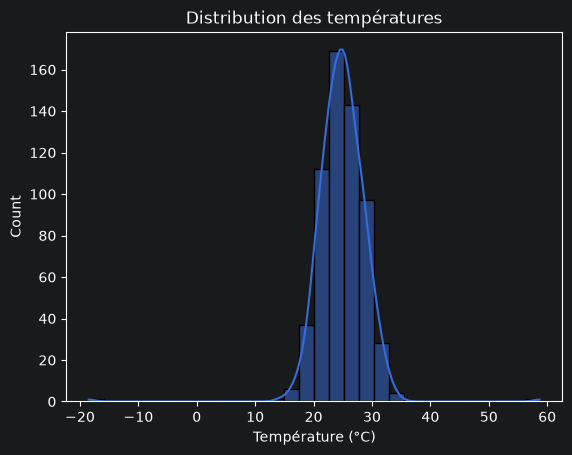

In [30]:
# data=df       -> DataFrame source
# x="temperature" -> colonne à découper en intervalles (axe des X)
# bins=30        -> nombre d'intervalles (plus il y en a, plus le détail est fin)
# kde=True       -> superpose une courbe de densité lissée par-dessus les barres
sns.histplot(data=df, x="temperature", bins=30, kde=True)

plt.title("Distribution des températures")   # titre du graphique
plt.xlabel("Température (°C)")                # étiquette de l'axe X
plt.show()                                    # affiche le graphique (obligatoire hors Jupyter inline)

### 2) Autour de quelle valeur les températures sont-elles concentrées ?
La majorité des mesures se concentrent **entre 20°C et 28°C**, avec un pic autour de **24-25°C**
(cohérent avec la moyenne globale d'environ 24,9°C calculée plus haut avec `describe()`).

### 3) La distribution semble-t-elle symétrique ?
Globalement oui, l'histogramme a une forme proche d'une cloche centrée autour de 24-25°C — mais on
observe une **légère traîne vers la droite** à cause des valeurs chaudes extrêmes (voir point suivant).

### 4) Existe-t-il des valeurs extrêmes ?
Oui : le minimum observé est **-18,5°C** et le maximum **58,7°C**, deux valeurs physiquement
improbables pour des relevés de température intérieure/bâtiment — probablement des erreurs de
capteur plutôt que des mesures réelles.

### 5) Modifier le nombre de classes (bins)

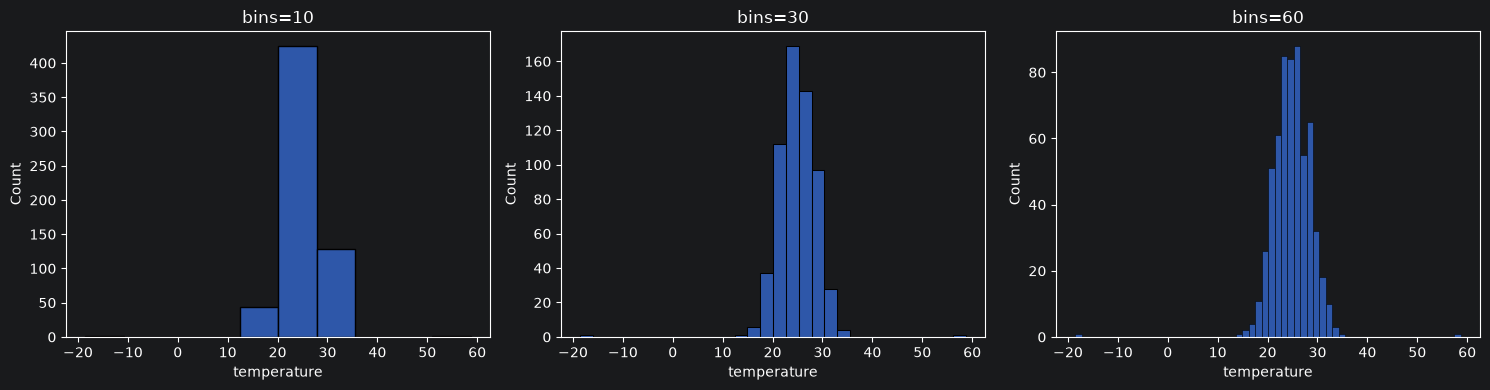

In [31]:
# On compare 3 découpages différents côte à côte pour voir l'effet du paramètre `bins`
fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # 1 ligne, 3 colonnes de graphiques

for ax, n_bins in zip(axes, [10, 30, 60]):
    # ax=ax : on dit à Seaborn de dessiner DANS le sous-graphique courant (et pas une nouvelle figure)
    sns.histplot(data=df, x="temperature", bins=n_bins, ax=ax)
    ax.set_title(f"bins={n_bins}")

plt.tight_layout()  # évite que les sous-graphiques se chevauchent
plt.show()

Avec **peu de classes (10)**, on perd le détail : la distribution paraît lisse mais on ne voit
plus les valeurs extrêmes isolées. Avec **beaucoup de classes (60)**, le graphique devient plus
« bruité » mais permet de mieux repérer les valeurs aberrantes individuelles (comme -18,5°C).
→ `bins` est donc un compromis entre lisibilité globale et détail fin.

### 6) Distribution des températures par bâtiment

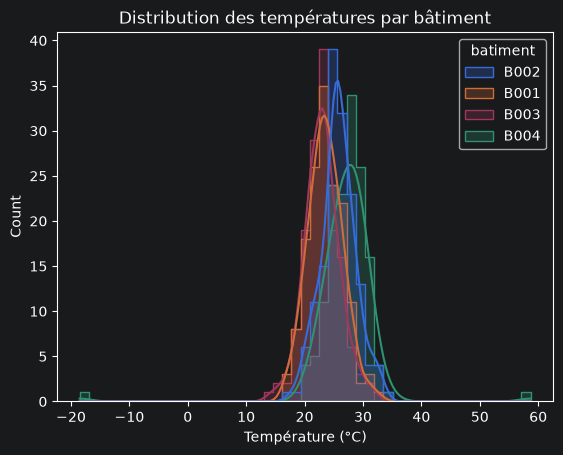

In [32]:
# hue="batiment" : Seaborn trace une distribution par catégorie de bâtiment, avec une couleur différente
# element="step"  : dessine des contours (escaliers) plutôt que des barres pleines, pour mieux superposer
sns.histplot(data=df, x="temperature", hue="batiment", kde=True, element="step")

plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.show()

On voit déjà que **B004** se distingue avec une distribution plus étalée que les 3 autres bâtiments.

# Partie 2 — Distribution d'une variable avec `kdeplot()`

**Objectif de `kdeplot()` :** au lieu de compter les observations par tranche (comme `histplot`),
on estime une **courbe de densité continue** à partir des points — plus lisse, plus facile à
superposer pour comparer plusieurs groupes.


### 1) Distribution des températures

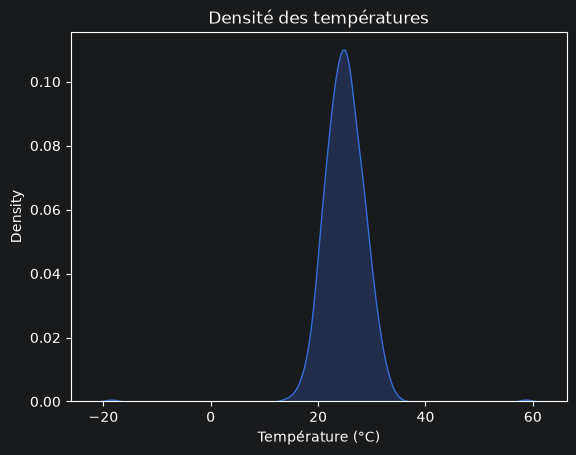

In [33]:
# fill=True : remplit la zone sous la courbe (plus lisible qu'une simple ligne)
sns.kdeplot(data=df, x="temperature", fill=True)
plt.title("Densité des températures")
plt.xlabel("Température (°C)")
plt.show()

### 2) Distribution des températures par bâtiment

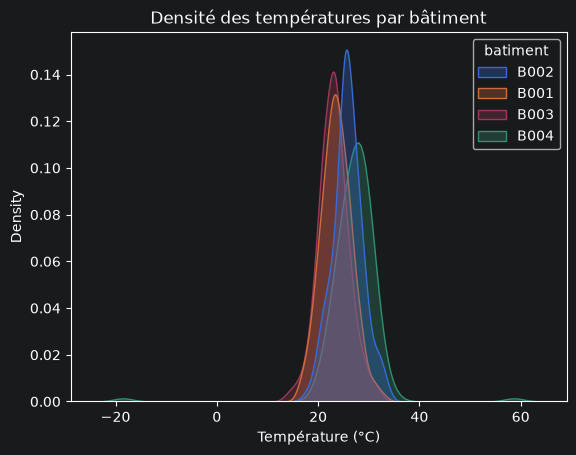

In [36]:
# hue="batiment"      -> une courbe par bâtiment
# common_norm=False    -> chaque courbe est normalisée indépendamment (sinon les bâtiments
#                         avec plus de mesures écraseraient visuellement les autres)
# alpha=0.3            -> transparence, pour bien voir les courbes qui se superposent
sns.kdeplot(data=df, x="temperature", hue="batiment", fill=True, common_norm=False, alpha=0.3)
plt.title("Densité des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.show()

La courbe de **B004** est nettement plus large et plus aplatie que celles de B001/B002/B003,
confirmant une plus grande dispersion des températures dans ce bâtiment.

# Partie 3 — Distribution d'une variable avec `boxplot()`

**Objectif de `boxplot()` :** résumer une distribution en quelques chiffres clés affichés
visuellement : médiane, quartiles (boîte), valeurs "normales" (moustaches), et points isolés
au-delà = valeurs aberrantes (outliers). Très utile pour **comparer plusieurs groupes** en un
coup d'œil.

### 1) Distribution des températures (ensemble)

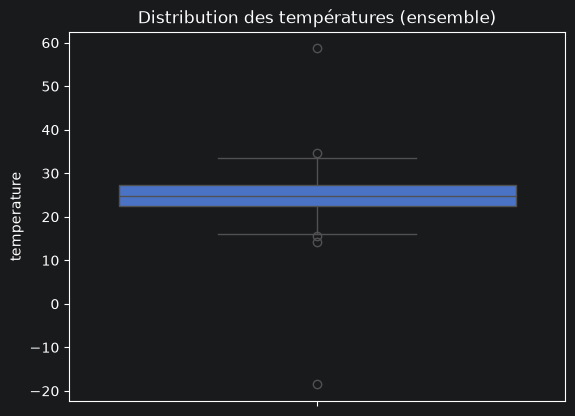

In [39]:
# y="temperature" (et pas x=) : on affiche un boxplot vertical pour une seule variable
sns.boxplot(data=df, y="temperature")
plt.title("Distribution des températures (ensemble)")
plt.show()

### 2) Distribution des températures par bâtiment

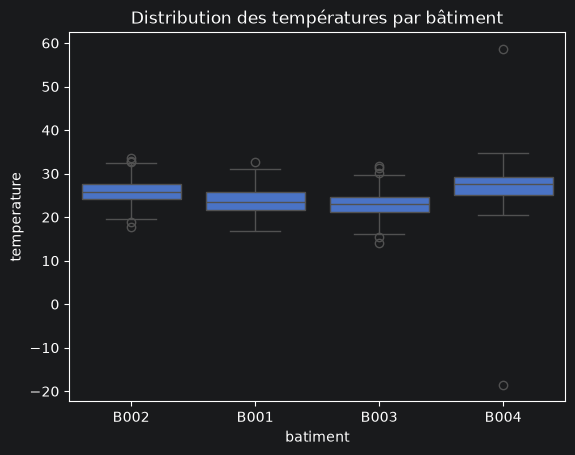

In [40]:
# x="batiment" -> une boîte par bâtiment, y="temperature" -> variable résumée dans chaque boîte
sns.boxplot(data=df, x="batiment", y="temperature")
plt.title("Distribution des températures par bâtiment")
plt.show()

In [41]:
# On calcule les statistiques exactes pour appuyer la lecture visuelle du boxplot
# groupby("batiment") regroupe les lignes par bâtiment, puis describe() calcule les stats par groupe
df.groupby("batiment")["temperature"].describe()[["50%", "std", "min", "max"]]
# 50% = médiane, std = écart-type (mesure de dispersion), min/max = valeurs extrêmes observées

,50%,std,min,max
batiment,,,,
B001,23.540,2.961211,16.77,32.72
B002,25.670,2.951828,17.67,33.60
B003,23.045,2.983902,14.11,31.74
B004,27.535,5.367361,-18.50,58.70


### 3) Pour chaque bâtiment

| Bâtiment | Médiane | Dispersion (écart-type) | Valeurs extrêmes |
|---|---|---|---|
| B001 | ≈ 23,5°C | ≈ 3,0°C | 16,8°C à 32,7°C — pas d'extrême marquant |
| B002 | ≈ 25,7°C | ≈ 3,0°C | 17,7°C à 33,6°C — bâtiment le plus « chaud » en médiane |
| B003 | ≈ 23,0°C | ≈ 3,0°C | 14,1°C à 31,7°C — bâtiment le plus « frais » en médiane |
| B004 | ≈ 27,5°C | ≈ 5,4°C | **-18,5°C et 58,7°C** — dispersion presque 2x plus grande que les autres |

* **a) Médiane :** B004 a la médiane la plus élevée (~27,5°C), B003 la plus basse (~23,0°C).
* **b) Dispersion :** B004 a un écart-type nettement supérieur (≈5,4°C contre ≈3,0°C ailleurs) — ses
températures sont beaucoup plus variables.
* **c) Valeurs extrêmes :** les points isolés au-delà des moustaches du boxplot de B004 (-18,5°C et
58,7°C notamment) sortent très largement de la plage des 3 autres bâtiments.

### 4) Quels bâtiments ont les valeurs les plus extrêmes ?
**B004**, sans ambiguïté : c'est le seul bâtiment avec des valeurs physiquement aberrantes
(température négative très basse et température très haute), et sa boîte est visuellement bien plus
large que les autres.